In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

In [2]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [3]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [4]:
design_matrix.shape

(680, 71)

In [5]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance", 
]

In [6]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [7]:
design_matrix_test['qsofa_resp'] = np.where(
    design_matrix_test['resp_frequency_ambulance'] >= 22, 1, 0
)

design_matrix_test['qsofa_sysbp'] = np.where(
    design_matrix_test['syst_bp_ambulance'] <= 100, 1, 0
)

design_matrix_test['qsofa_mental'] = np.where(
    design_matrix_test['mental_status_ambulance'] > 1, 1, 0
)

In [8]:
qsofa_columns = [
    'qsofa_resp',
    'qsofa_sysbp',
    'qsofa_mental',
]

In [9]:
design_matrix_test['qsofa'] = design_matrix_test[qsofa_columns].sum(axis=1)

<Axes: >

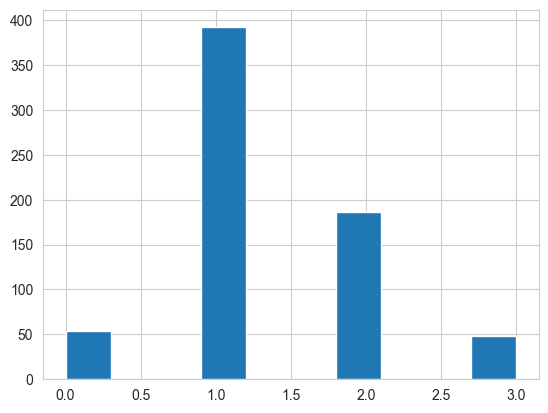

In [10]:
design_matrix_test['qsofa'].hist()

In [11]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])


In [12]:
df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    bootstrap_replace=False,
    bootstrap_fraction=0.9,
    bootstrap_iterations=1000
)
df_estimator.fit(training_data, features=clinical_columns)

In [13]:
testing_data['Mortality 30 Day Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="survival_30_day",
    bootstrap=True
)

In [14]:
testing_data['Future Deterioration Mean'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="future_deterioration",
    bootstrap=True
)

In [15]:
testing_data['Sepsis Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock",
    bootstrap=True
)

In [16]:
testing_data['Infection Prob'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="verified_infection",
    bootstrap=True
)

In [17]:
from sklearn.metrics import RocCurveDisplay, roc_curve

In [18]:

from sklearn.calibration import calibration_curve, CalibrationDisplay


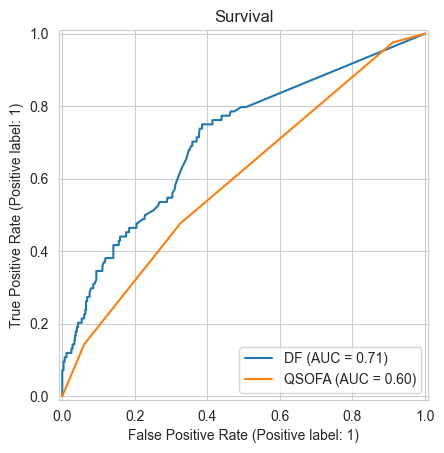

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data['Mortality 30 Day Prob'],
    ax=ax,
    name="DF"
)

RocCurveDisplay.from_predictions(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data['qsofa'],
    ax=ax,
    name="QSOFA"
)

ax.set_title("Survival")

fig.savefig("survival.png")

Text(0.5, 1.0, 'Survival')

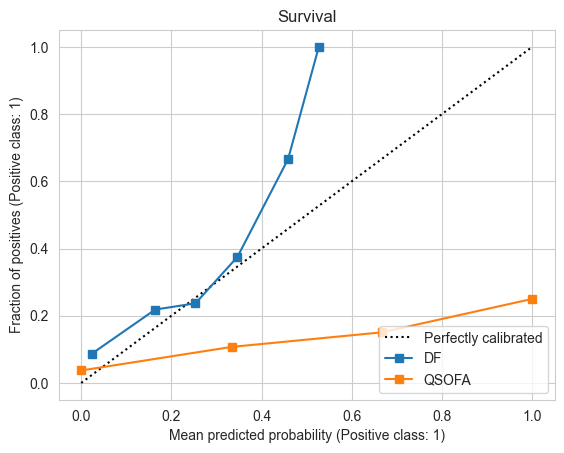

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

CalibrationDisplay.from_predictions(
    y_true=testing_data['survival_30_day'],
    y_prob=testing_data['Mortality 30 Day Prob'],
    ax=ax,
    name="DF",
    n_bins=10
)

CalibrationDisplay.from_predictions(
    y_true=testing_data['survival_30_day'],
    y_prob=testing_data['qsofa'] / 3,
    ax=ax,
    name="QSOFA",
    n_bins=10
)

ax.set_title("Survival")

<Axes: >

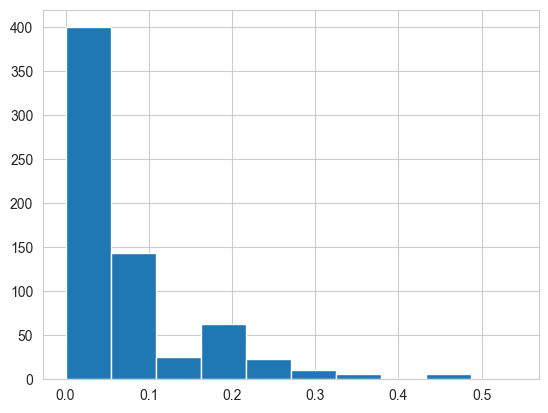

In [21]:
testing_data['Mortality 30 Day Prob'].hist()

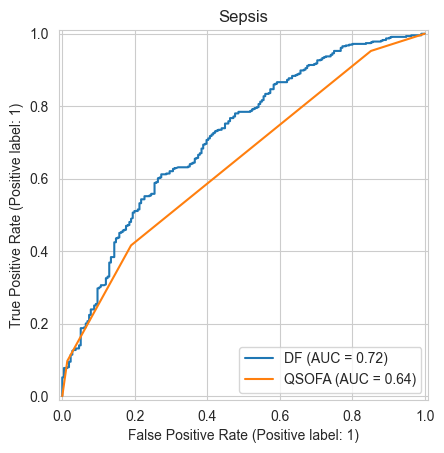

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(
    y_true=testing_data['sepsis_or_septic_shock'],
    y_score=testing_data['Sepsis Prob'],
    ax=ax,
    name="DF"
)

RocCurveDisplay.from_predictions(
    y_true=testing_data['sepsis_or_septic_shock'],
    y_score=testing_data['qsofa'],
    ax=ax,
    name="QSOFA"
)



ax.set_title("Sepsis")
fig.savefig("sepsis.png")

Text(0.5, 1.0, 'Sepsis')

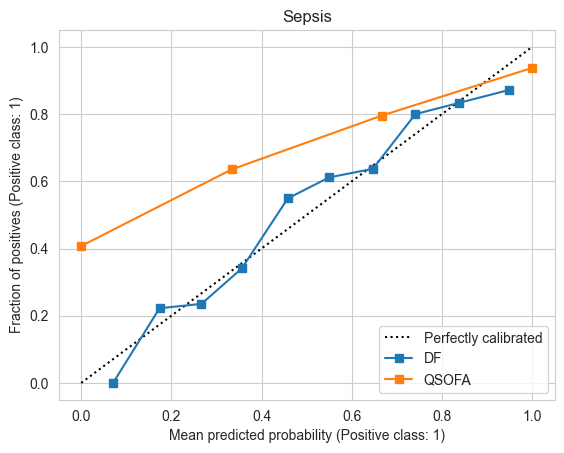

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

CalibrationDisplay.from_predictions(
    y_true=testing_data['sepsis_or_septic_shock'],
    y_prob=testing_data['Sepsis Prob'],
    ax=ax,
    name="DF",
    n_bins=10
)

CalibrationDisplay.from_predictions(
    y_true=testing_data['sepsis_or_septic_shock'],
    y_prob=testing_data['qsofa'] / 3,
    ax=ax,
    name="QSOFA",
    n_bins=10
)



ax.set_title("Sepsis")

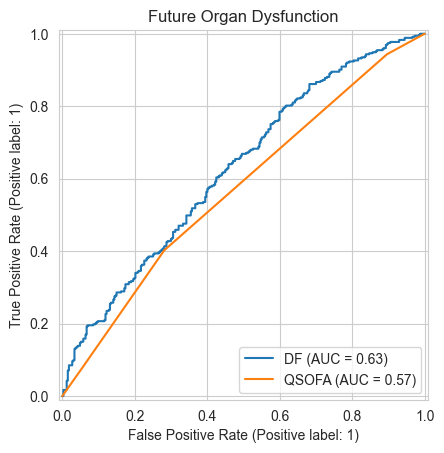

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(
    y_true=testing_data['future_deterioration'],
    y_score=testing_data['Future Deterioration Mean'],
    ax=ax,
    name="DF"
)

RocCurveDisplay.from_predictions(
    y_true=testing_data['future_deterioration'],
    y_score=testing_data['qsofa'],
    ax=ax,
    name="QSOFA"
)


ax.set_title("Future Organ Dysfunction")
fig.savefig("organ_dysfunction.png")

Text(0.5, 1.0, 'Organ Dysfunction')

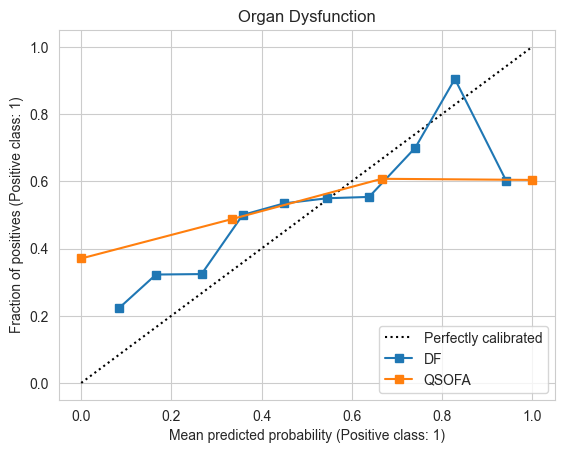

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

CalibrationDisplay.from_predictions(
    y_true=testing_data['future_deterioration'],
    y_prob=testing_data['Future Deterioration Mean'],
    ax=ax,
    name="DF",
    n_bins=10
)

CalibrationDisplay.from_predictions(
    y_true=testing_data['future_deterioration'],
    y_prob=testing_data['qsofa'] / 3,
    ax=ax,
    name="QSOFA",
    n_bins=10
)


ax.set_title("Organ Dysfunction")

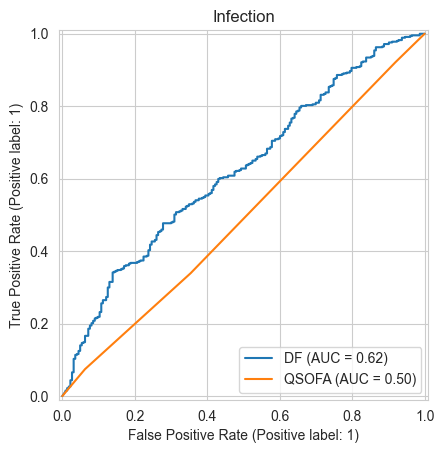

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(
    y_true=testing_data['verified_infection'],
    y_score=testing_data['Infection Prob'],
    ax=ax,
    name="DF"
)

RocCurveDisplay.from_predictions(
    y_true=testing_data['verified_infection'],
    y_score=testing_data['qsofa'],
    ax=ax,
    name="QSOFA"
)


ax.set_title("Infection")
fig.savefig("infection.png")

Text(0.5, 1.0, 'Infection')

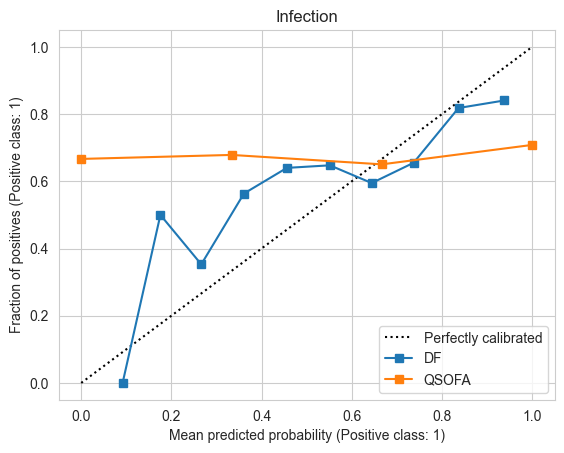

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

CalibrationDisplay.from_predictions(
    y_true=testing_data['verified_infection'],
    y_prob=testing_data['Infection Prob'],
    ax=ax,
    name="DF",
    n_bins=10
)

CalibrationDisplay.from_predictions(
    y_true=testing_data['verified_infection'],
    y_prob=testing_data['qsofa'] / 3,
    ax=ax,
    name="QSOFA",
    n_bins=10
)

ax.set_title("Infection")

In [28]:
sepsis_rate = testing_data['sepsis_or_septic_shock'].value_counts()
sepsis_rate[1] / (sepsis_rate[1] + sepsis_rate[0])

0.6823529411764706

In [29]:


testing_data['Infection Std'] = df_estimator.bootstrap_results_df.std(axis=1)


<Axes: xlabel='Infection Std', ylabel='Count'>

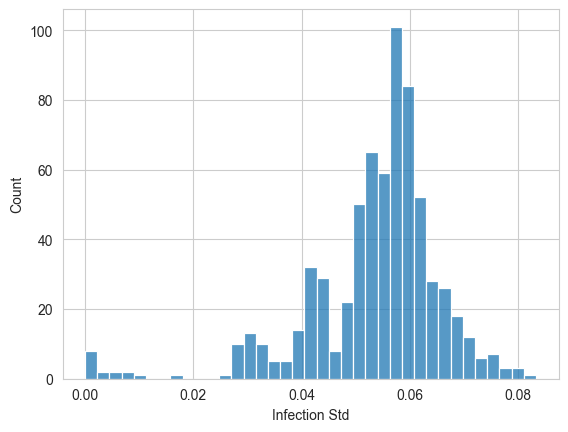

In [30]:
sns.histplot(
    data=testing_data,
    x="Infection Std",
)

<Axes: xlabel='Infection Std', ylabel='Infection Prob'>

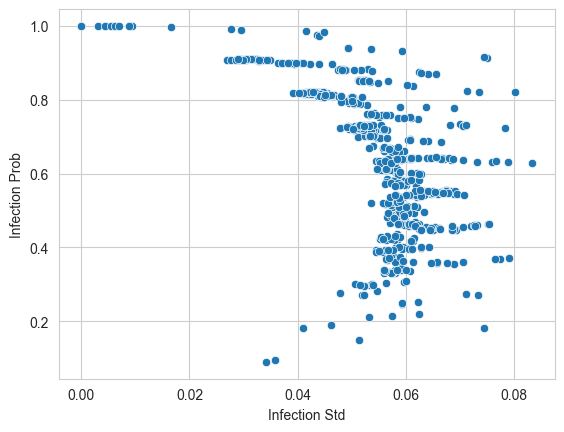

In [31]:
sns.scatterplot(
    data=testing_data,
    x="Infection Std",
    y="Infection Prob",
)